In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal, init_to_median
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.signal import savgol_filter
import gc
import os


# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from utils.data_generator import DataGenerator
from utils.methods_2 import evaluate_metrics
from utils.recursive_inference import recursive_inference
from utils.zoomed_plots import zoomed_plots

In [2]:
# Load the MAT file for training and validation
mat_file = sio.loadmat('./real_data/100307.REST1.LR.SchaeferS.ptseries.mat')
data = torch.from_numpy(mat_file['tseries']).float()

In [3]:
# decomment if reading from file:
best_params = pd.read_csv("./best_parameters_SVI/best_parameters.csv")
pyro.clear_param_store()
best_params = best_params.set_index('parameter')['value']
# PARAMETERS

N_NEURONS = int(best_params['neurons'])
INPUT_DIM = data.shape[0] # equals to output dim

LR = float(best_params['lr'])
act_name = nn.Tanh() if best_params['activation'] == 'Tanh()' else nn.ReLU()
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius = float(best_params['spectral_radius']),
    scale = float(best_params['scale'])
)

esn_var.reservoir.activation = act_name

In [4]:
train_ds, _ = construct_dataset(esn_var.reservoir, data.T, train_split=1.0, burnin=100, noise = False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
# retrain on the full first dataset
history = esn_var.train(train_loader, EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:04<08:03,  4.89s/it, Loss=1060.6122]

Epoch 0 | Total ELBO Loss: 1060.6122


Training Pyro ESN: 100%|██████████| 100/100 [00:48<00:00,  2.08it/s, Loss=625.1103]


In [5]:
# fetch test dataset
data_test = torch.from_numpy(sio.loadmat('./real_data/100307.REST2.LR.SchaeferS.ptseries.mat')['tseries']).float()

In [6]:
# Generate Torch datasets
test_ds, _ = construct_dataset(esn_var.reservoir, data_test.T, train_split=1.0, burnin=0, noise = False)

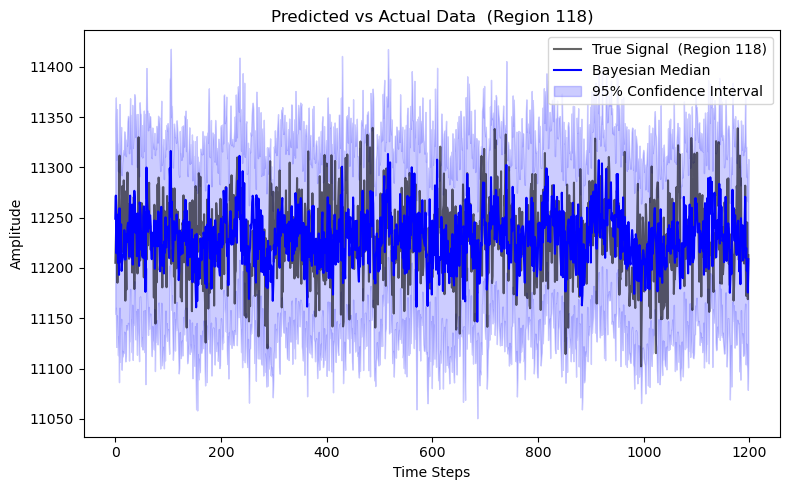

In [7]:
scaler = {"mean": test_ds.mean, "std": test_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000, region_idx=118)

In [8]:
n_trials = 5
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values

results = {"avg_ecov": np.zeros(n_trials), "avg_cal": np.zeros(n_trials), "avg_mcrps": np.zeros(n_trials)}

for i in range(n_trials):
    y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, plot = False, num_samples = 1000)
    ecov, cal, mcrps = evaluate_metrics(y_samples, y_true)

    n_mcrps = mcrps / ranges
    results["avg_ecov"][i] = ecov.mean().item()
    results["avg_cal"][i] = cal.mean().item()
    results["avg_mcrps"][i] = n_mcrps.mean().item()



In [9]:
result_df = pd.DataFrame(results)

In [12]:
result_df.to_csv("metrics_radial.csv", index = False)